# 1.LangSmith的使用

LangChain生态系统中专门用于LLM应用**调试、监控、评估和管理**的平台  
- **调试(tracing)**:记录每次LLM调用的详细信息 
- **监控(monitoring)**：实施查看应用性能  
- **调试(debug)**:排查问题和优化性能  
- **评估(evaluate)**:系统化测试LLM应用


langsmith和langchain因为是同一生态，只要配置好env文件：  
LANGCHAIN_TRACING_V2=true  
LANGCHAIN_API_KEY=ls_xxxxxxxxxxxxxxxxxxxx  
LANGCHAIN_PROJECT=test_project  
LANGCHAIN_ENDPOINT=https://api.smith.langchain.com  

<span style="color:red;">代码中无需任何操作</span>

In [1]:
from dotenv import load_dotenv
from langchain_deepseek import ChatDeepSeek
import os

load_dotenv(override=True)  # 表示.env文件优先
# 强制开启追踪，兜底防止.env没加载到
# os.environ["LANGCHAIN_TRACING_V2"] = "true"
model =ChatDeepSeek(
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    model="deepseek-v4-flash"
)

print(model.invoke("你好"))

content='你好！有什么可以帮你的吗？' additional_kwargs={'refusal': None, 'reasoning_content': 'We need respond in Chinese. Need maybe greeting. User says 你好. Need answer friendly.'} response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 84, 'total_tokens': 112, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 19, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 84}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_a18b46594c_prod0820_fp8_kvcache_20260402', 'id': '1a67ed8d-10b3-45ef-921d-10a18696ae7f', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fd619-2f1d-7402-8e93-abff322d8449-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 84, 'output_tokens': 28, 'total_tokens': 112, 'input_token_details': {'cache_read': 0}, 'output_token_det

LangSmith可以监控
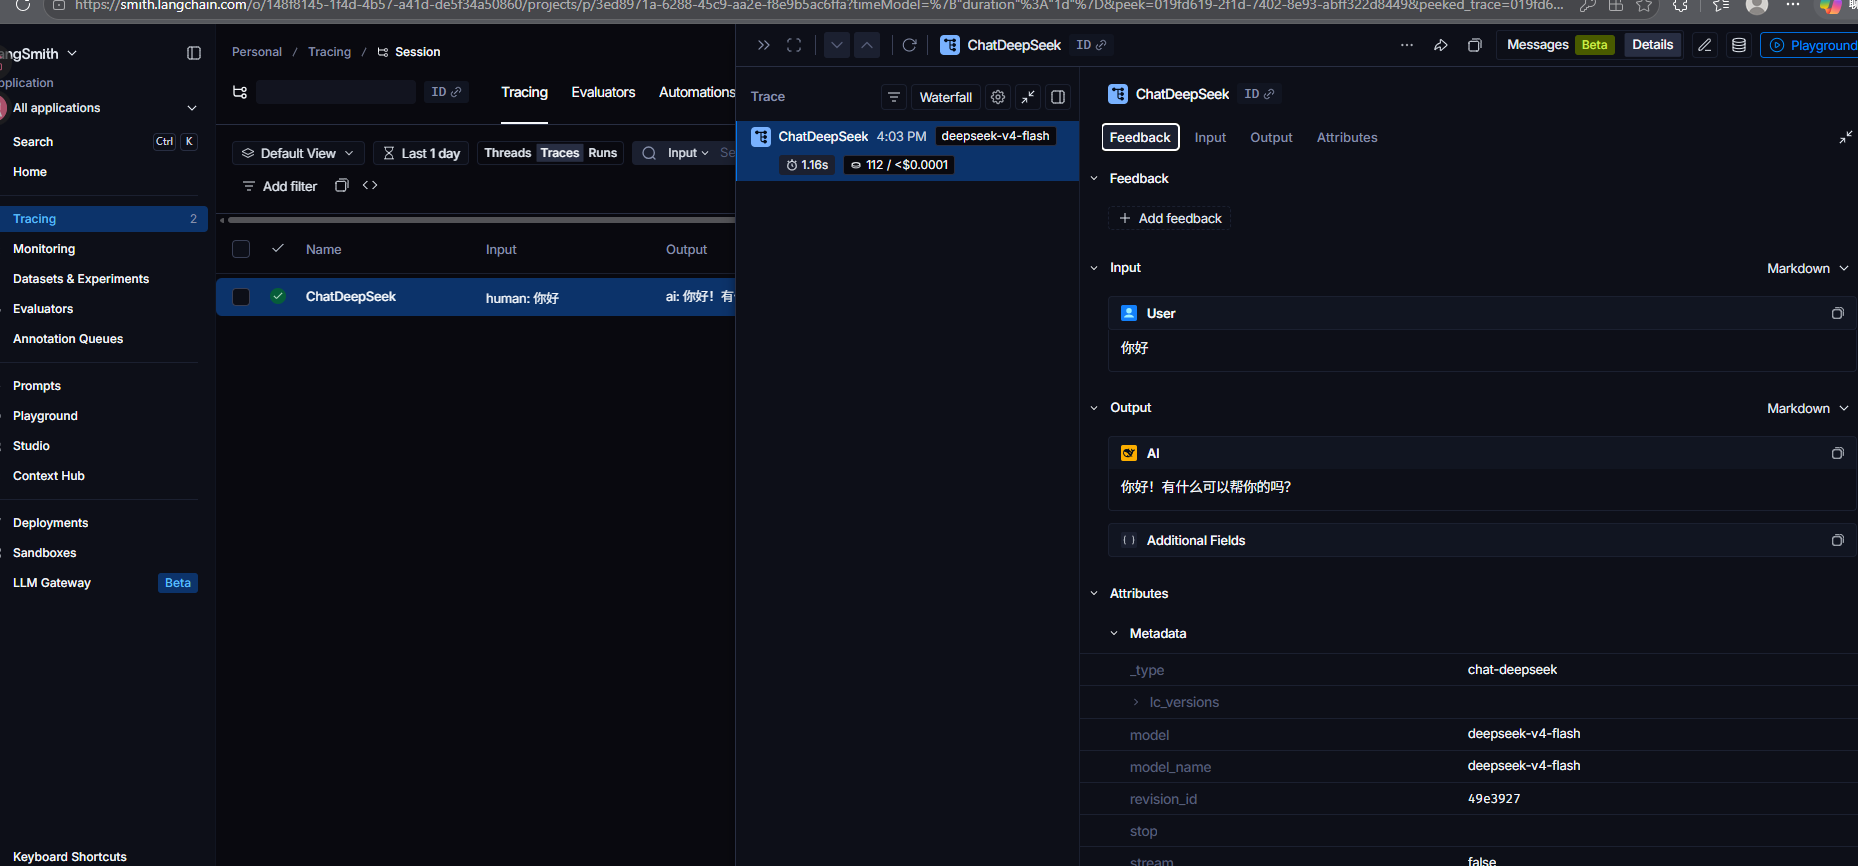

In [2]:
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
import os

# 从.env文件中加载环境变量
load_dotenv(override=True)

model = ChatOpenAI(
    model="Pro/MiniMaxAI/MiniMax-M2.5",
    temperature=0.7,
    max_tokens=1000,
    max_retries=6,
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL")
)

print(model.invoke("1+2=？"))

content='\n\n3' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 43, 'total_tokens': 178, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': None, 'reasoning_tokens': 133, 'rejected_prediction_tokens': None}, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 43}, 'model_provider': 'openai', 'model_name': 'Pro/MiniMaxAI/MiniMax-M2.5', 'system_fingerprint': '', 'id': '019fd61ada14ec2302206990e1ecd6e5', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fd61a-ddb3-7be2-9014-55c3bcf6ec2d-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 43, 'output_tokens': 135, 'total_tokens': 178, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 133}}


监控结果：
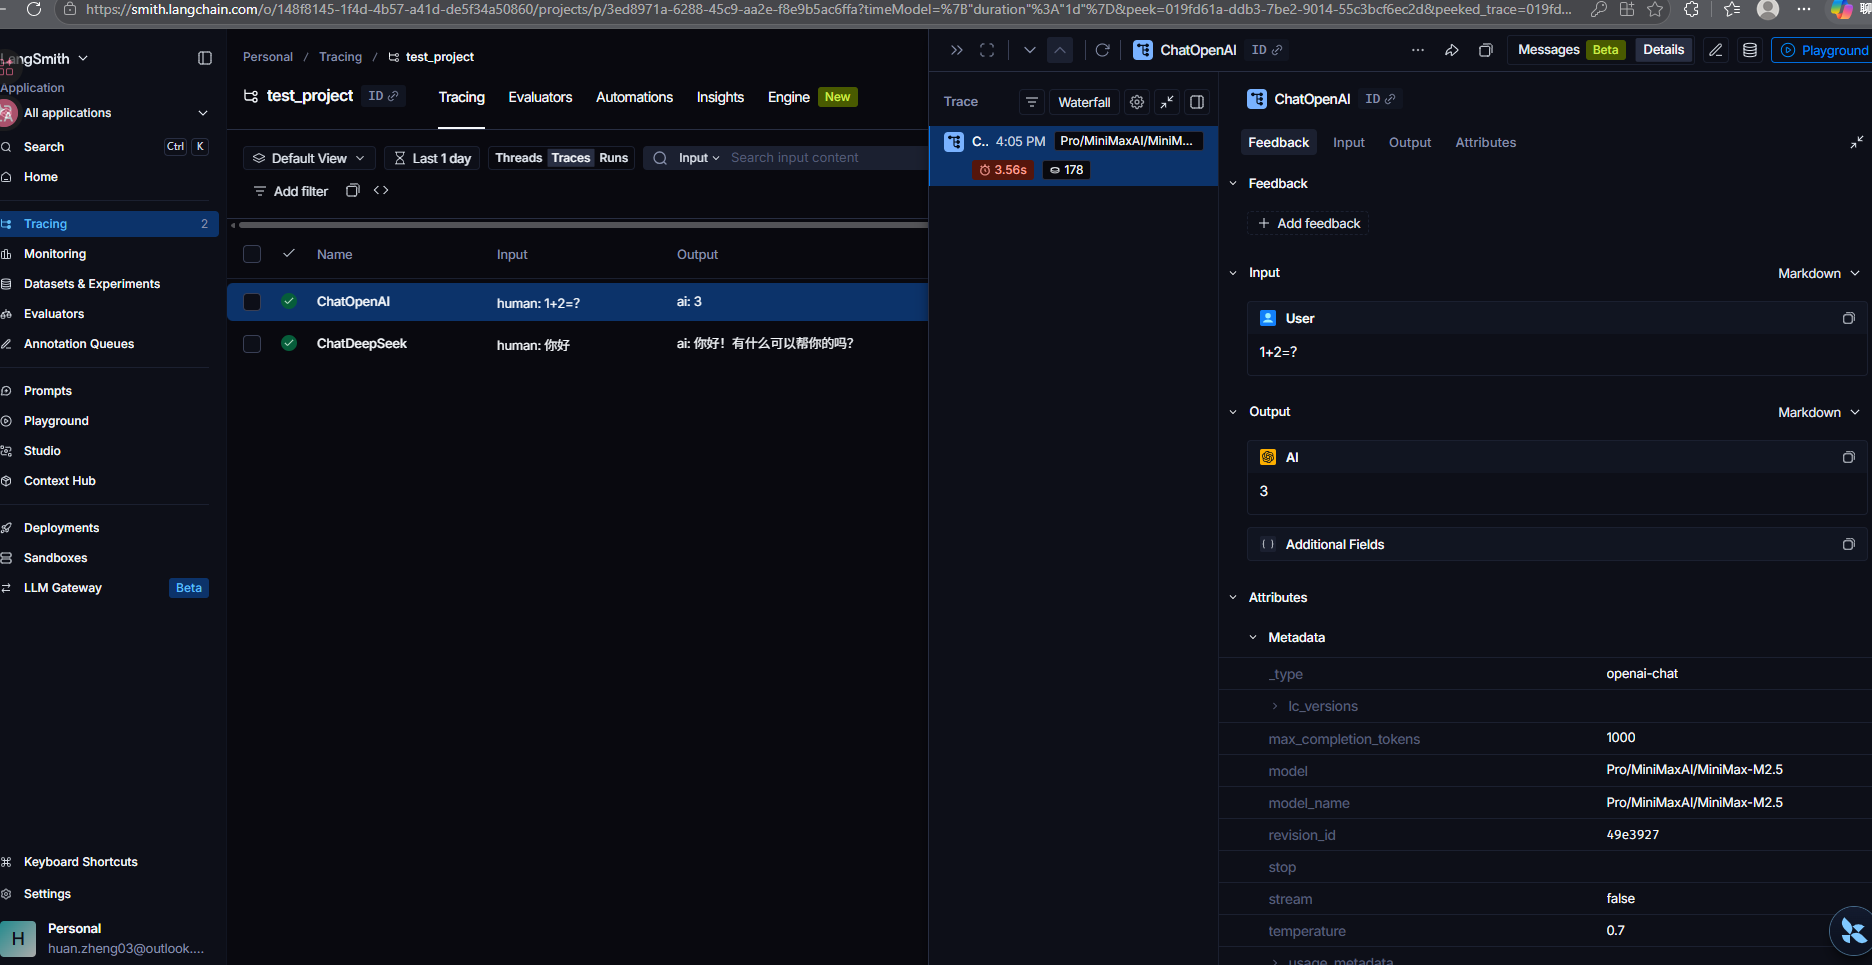

In [3]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from rich import print as rprint

load_dotenv()

llm = init_chat_model(
    model="zai-org/GLM-5.2",
    model_provider="openai",
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL"),
    temperature=0.5,
    max_tokens=200,
    # 指定可调整的参数
    configurable_fields=["model","model_provider","temperature","max_tokens"],
)

config = {
    "run_name":"joke_generation",    # 在LangSmith中这次运行会显示为"joke_generation"
    "tags":["my_tag1","my_tag2"],          # 打上标签便于分类查找
    "metadata":{
        "user_id":"victorzh",        # 记录用户ID
        "session_id":"sess_123"      # 记录会话ID
    },    
    "configurable":{
        "model":"deepseek-ai/DeepSeek-V4-Flash",   # 配置模型参数
        "model_provider":"deepseek", # 配置模型提供商
        "temperature":0.7,           # 配置温度参数
        "max_tokens":1000            # 配置最大令牌数
    }
}

# 调用模型并传入config
res = llm.invoke("2*5=？",config=config)
rprint(res)

AIMessage(
    content='2*5=10',
    additional_kwargs={
        'refusal': None,
        'reasoning_content': 'We are asked: "2*5=？" This is a simple multiplication problem. The answer is 10. But
the user wrote it in Chinese? Actually it\'s just "2*5=？". So answer: 10.'
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 55,
            'prompt_tokens': 88,
            'total_tokens': 143,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 50,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 88
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-ai/DeepSeek-V4-Flash',
        'system_fingerprint': '',
        'id': '019fd61bfc81215fd4fcd7dd4fe5927b',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019fd61c-0075-7330-b4cf-25d10e2f8a29-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 88,
        'output_tokens': 55,
        'total_tokens': 143,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 50}
    }
)

监控结果：
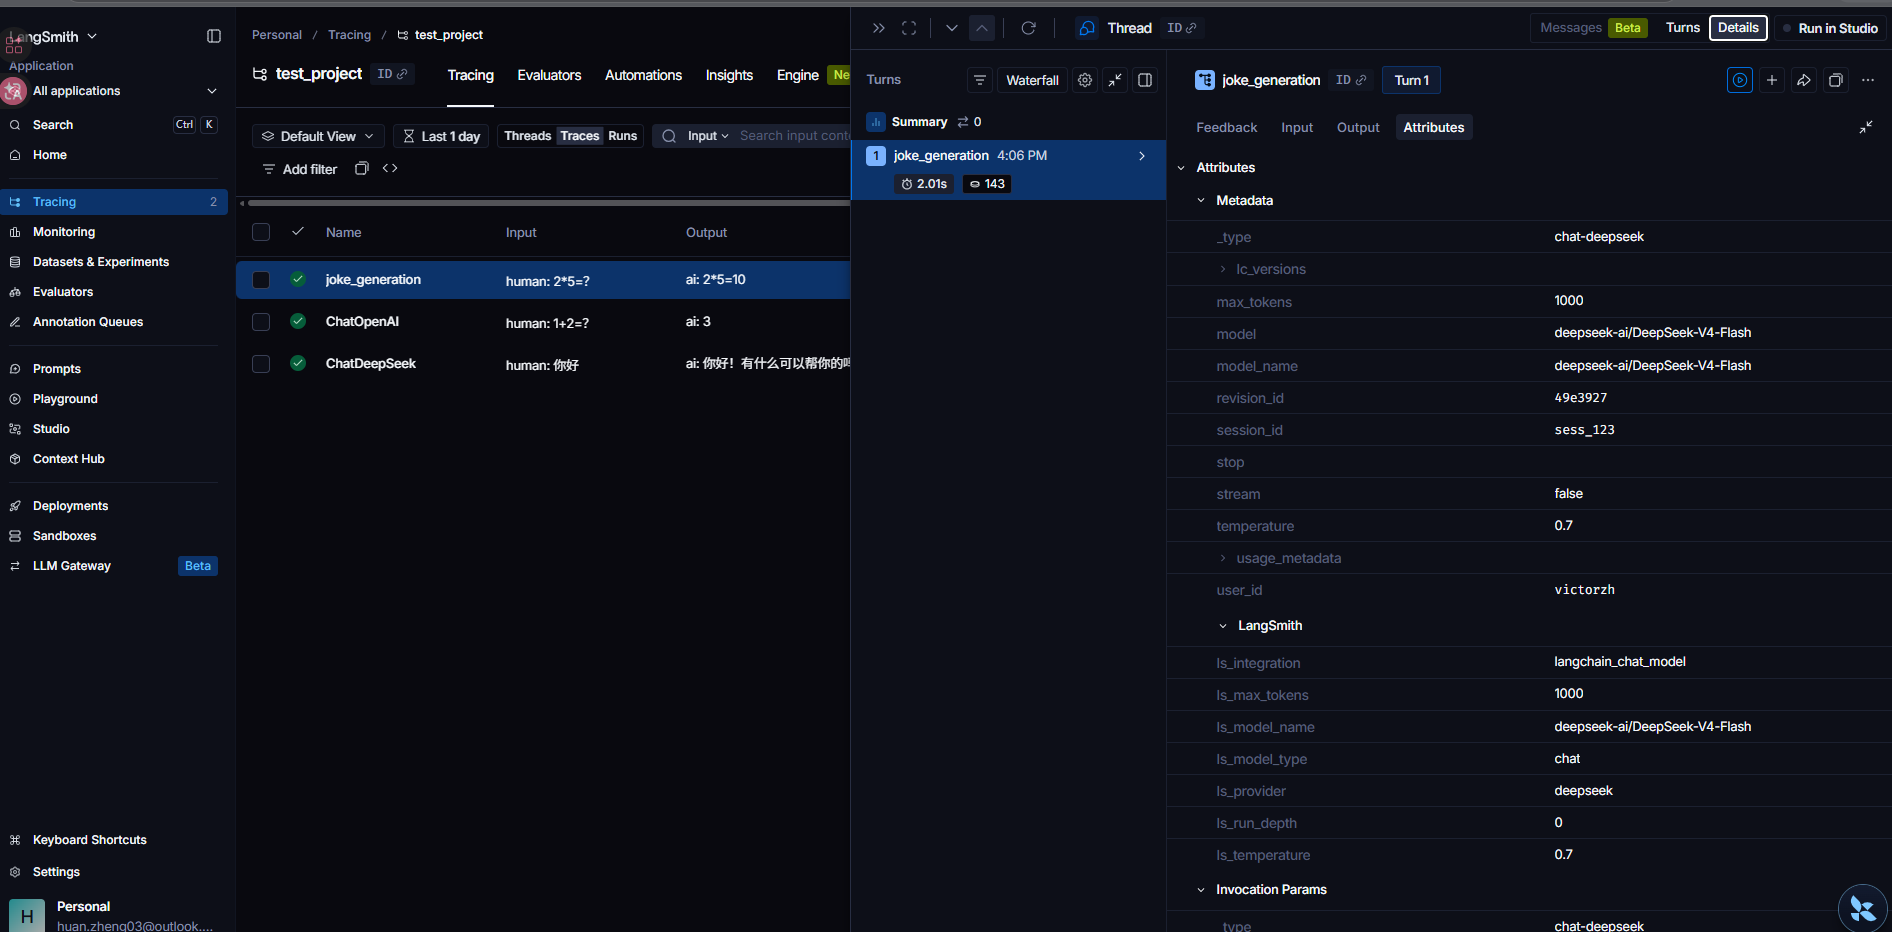

# 2.Langfuse本地化部署及使用
## 1）Langfuse本地部署
使用docekr部署

In [ ]:
# git 拉取项目到本地
git clone https://github.com/langfuse/langfuse.git
# 切换到项目文件路径
cd langfuse
# docker compose启动
docker compose up

注意本地部署有可能端口冲突  
到docker compose.yaml文件中修改端口保存

In [ ]:
docker-compose down

docker compoes up -d

就可以通过  
http://localhost:3000登录langfuse  
langfuse的setting可以创建APIkey  
配置到项目.env文件  

env配置：
#LANGFUSE配置  
LANGFUSE_SECRET_KEY="sk-lf-8021cd20-562f-40ac-a04f-89bdcc29e1cf"  
LANGFUSE_PUBLIC_KEY="pk-lf-9e096ed5-9e84-4d3d-ab96-f6823c8366e4"  
LANGFUSE_BASE_URL="http://localhost:3000"

代码中只要加入下面的设置即可： 

In [ ]:
# 1. 初始化Langfuse，自动读.env变量
langfuse = Langfuse()
# 生成LangChain回调处理器
lf_handler = CallbackHandler()

# 模型初始化需要在config参数加入参数
"callbacks":[lf_handler]

## 2）代码tracing举例

In [1]:
import os
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from rich import print as rprint
from langfuse import Langfuse
from langfuse.langchain import CallbackHandler


load_dotenv(r"C:\Users\huan.zheng\myproject\LangChainLearning\.env")

# 1. 初始化Langfuse，自动读.env变量
langfuse = Langfuse()
# 生成LangChain回调处理器
lf_handler = CallbackHandler()

llm = init_chat_model(
    model="zai-org/GLM-5.2",
    model_provider="openai",
    api_key=os.getenv("SILICON_API_KEY"),
    base_url=os.getenv("SILICON_BASE_URL"),
    temperature=0.5,
    max_tokens=200,
    # 指定可调整的参数
    configurable_fields=["model","model_provider","temperature","max_tokens"],
)

config = {
    "run_name":"calculate",    # 在Langfuse中这次运行会显示为"calculate"
    "tags":["my_tag1","my_tag2"],          # 打上标签便于分类查找
    "metadata":{
        "user_id":"victorzh-01",        # 记录用户ID
        "session_id":"sess_124"      # 记录会话ID
    },    
    "configurable":{
        "model":"deepseek-ai/DeepSeek-V4-Flash",   # 配置模型参数
        "model_provider":"deepseek", # 配置模型提供商
        "temperature":0.7,           # 配置温度参数
        "max_tokens":1000            # 配置最大令牌数
    },
    "callbacks":[lf_handler]         # 在配置中加入langfuse连接
}

# 调用模型并传入config
res = llm.invoke("5*800=？",config=config)
rprint(res)

c:\Users\huan.zheng\AppData\Local\miniconda3\envs\langchain1\Lib\site-packages\langgraph\checkpoint\base\__init__.py:17: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


AIMessage(
    content='5乘以800等于4000。',
    additional_kwargs={
        'refusal': None,
        'reasoning_content': '我们被问到："5*800=？" 
这是一个简单的乘法问题。5乘以800等于4000。所以答案应该是4000。但用户可能期望一个直接的答案。由于这是一个中文问题，
我们可以用中文回答。但作为AI，我们应该给出正确的数学答案。所以回答：4000。'
    },
    response_metadata={
        'token_usage': {
            'completion_tokens': 71,
            'prompt_tokens': 88,
            'total_tokens': 159,
            'completion_tokens_details': {
                'accepted_prediction_tokens': None,
                'audio_tokens': None,
                'reasoning_tokens': 64,
                'rejected_prediction_tokens': None
            },
            'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
            'prompt_cache_hit_tokens': 0,
            'prompt_cache_miss_tokens': 88
        },
        'model_provider': 'deepseek',
        'model_name': 'deepseek-ai/DeepSeek-V4-Flash',
        'system_fingerprint': '',
        'id': '019fd6273b41ca8e6de76c9dbeda3862',
        'finish_reason': 'stop',
        'logprobs': None
    },
    id='lc_run--019fd627-3f32-7aa3-87a8-7ac75a2e8be4-0',
    tool_calls=[],
    invalid_tool_calls=[],
    usage_metadata={
        'input_tokens': 88,
        'output_tokens': 71,
        'total_tokens': 159,
        'input_token_details': {'cache_read': 0},
        'output_token_details': {'reasoning': 64}
    }
)

结果：
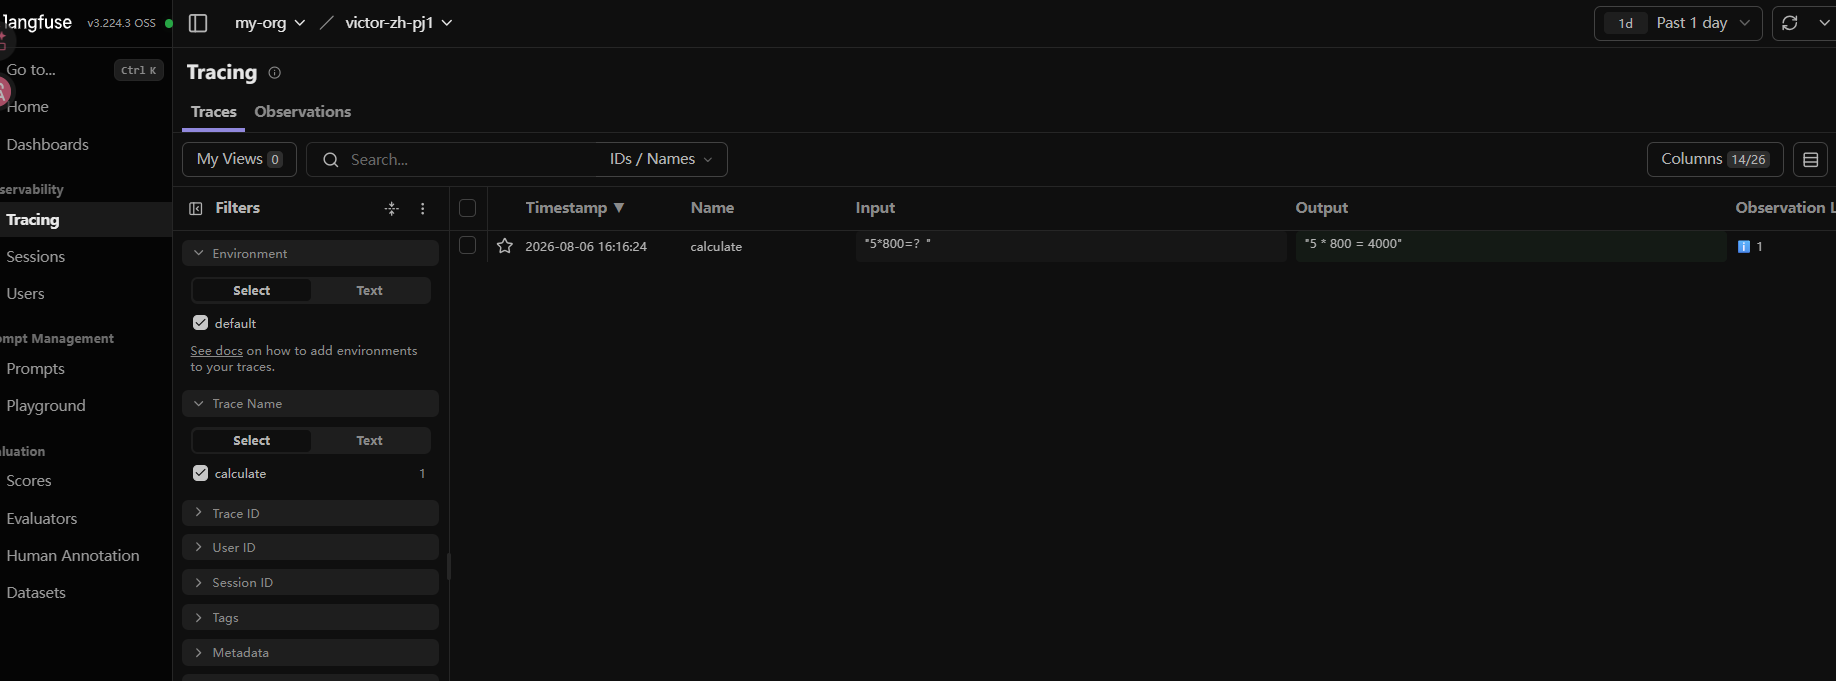